# Limpieza de Datos - Sistema Recomendador (AZ)
Objetivo: dejar `interacciones_clean + productos_clean + usuarios_clean` listos para el híbrido ML+DL.
Mapeo: historial=`compra_verificada+fecha` | preferencias=`rating+texto` | comportamiento=`usuarios_clean`.
Ejecutar de arriba hacia abajo: cada celda muestra su salida para exponer.

In [1]:
import os, html, re
import pandas as pd
import matplotlib.pyplot as plt

RAW = os.path.join('data', 'raw')
OUT = os.path.join('data', 'processed_az')
os.makedirs(OUT, exist_ok=True)
print('Rutas OK:', RAW, '->', OUT)

Rutas OK: data\raw -> data\processed_az


## 1. Importar dataset + 2. Estructura (`head`, `shape`)

In [2]:
r = pd.read_csv(os.path.join(RAW, 'resenas.csv'))
p = pd.read_csv(os.path.join(RAW, 'productos.csv'))
print(f'resenas: {r.shape} | productos: {p.shape}')
display(r.head(2))
display(p.head(2))

resenas: (204382, 8) | productos: (71214, 7)


,user_id,product_id,rating,fecha,titulo_resena,texto_resena,texto,compra_verificada
0,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,az_B00LOPVX74,5,2020-01-09,Pretty locket,I think this locket is really pretty. The insi...,Pretty locket. I think this locket is really p...,True
1,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,az_B07F2BTFS9,1,2018-12-31,Wonâ€™t buy again,Crappy socks. Money wasted. Bought to wear wit...,Wonâ€™t buy again. Crappy socks. Money wasted....,True


,product_id,titulo,tienda,precio,rating_promedio,numero_resenas,texto_producto
0,az_1574998102,Compact 1 Reading Glasses - Tortoise +3.00,Nannini,NaN,5.0,1,Compact 1 Reading Glasses - Tortoise +3.00. no...
1,az_6152004349,freeband Fullmetal Alchemist Cosplay Costume A...,freeband,NaN,4.0,35,freeband Fullmetal Alchemist Cosplay Costume A...


## 3. Tipos de datos (`info`, `dtypes`)

In [3]:
print('--- resenas.info() ---')
r.info()
print(r.dtypes.to_string())
print('\n--- productos.info() ---')
p.info()

--- resenas.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 204382 entries, 0 to 204381
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   user_id            204382 non-null  str  
 1   product_id         204382 non-null  str  
 2   rating             204382 non-null  int64
 3   fecha              204382 non-null  str  
 4   titulo_resena      204340 non-null  str  
 5   texto_resena       204324 non-null  str  
 6   texto              204369 non-null  str  
 7   compra_verificada  204382 non-null  bool 
dtypes: bool(1), int64(1), str(6)
memory usage: 11.1 MB
user_id                str
product_id             str
rating               int64
fecha                  str
titulo_resena          str
texto_resena           str
texto                  str
compra_verificada     bool

--- productos.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 71214 entries, 0 to 71213
Data columns (total 7 columns):
 #   Column  

## 4. Valores faltantes

In [4]:
print('Nulos resenas (%):')
print((r.isnull().mean()*100).round(2).to_string())
print('\nNulos productos (%):')
print((p.isnull().mean()*100).round(2).to_string())
print('\nLectura: precio ~90% nulo -> no sera feature core, se imputa + flag.')

Nulos resenas (%):
user_id              0.00
product_id           0.00
rating               0.00
fecha                0.00
titulo_resena        0.02
texto_resena         0.03
texto                0.01
compra_verificada    0.00

Nulos productos (%):
product_id          0.00
titulo              0.03
tienda              3.15
precio             89.77
rating_promedio     0.00
numero_resenas      0.00
texto_producto      0.00

Lectura: precio ~90% nulo -> no sera feature core, se imputa + flag.


## 5. Duplicados + 6. Descriptiva

In [5]:
print('dup user-producto:', r.duplicated(['user_id','product_id']).sum())
print('dup product_id:', p.duplicated('product_id').sum())
display(r['rating'].describe())
print(r['rating'].value_counts(normalize=True).round(3).to_string())
print('fecha:', r['fecha'].min(), '->', r['fecha'].max())

dup user-producto: 1529
dup product_id: 0


count    204382.000000
mean          4.106790
std           1.325419
min           1.000000
25%           3.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64

rating
5    0.603
4    0.145
3    0.099
1    0.091
2    0.063
fecha: 2004-02-04 -> 2023-04-10


## 7. Variables + 8. Visualizaciones

compra_verificada
True     190253
False     14129
tienda
Nike           345
GRACE KARIN    307
Verdusa        284
Disney         277
Floerns        262


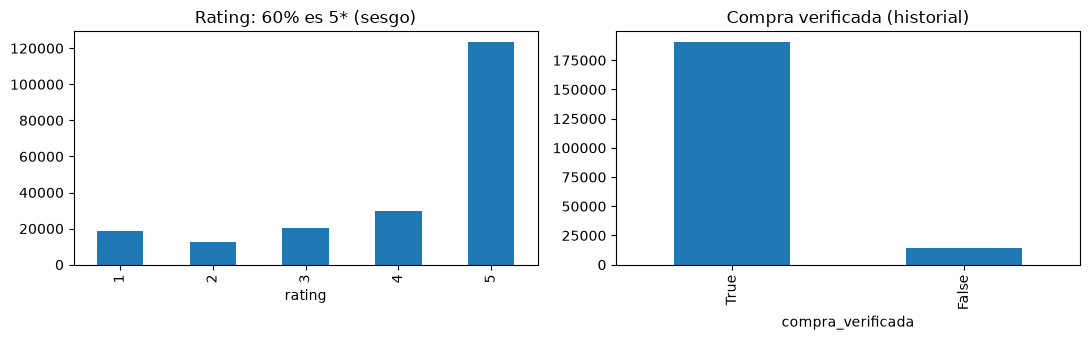

Cobertura resenas->catalogo: 100.0%


In [6]:
print(r['compra_verificada'].value_counts().to_string())
print(p['tienda'].value_counts().head(5).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
r['rating'].value_counts().sort_index().plot(kind='bar', ax=ax[0], title='Rating: 60% es 5* (sesgo)')
r['compra_verificada'].astype(str).value_counts().plot(kind='bar', ax=ax[1], title='Compra verificada (historial)')
plt.tight_layout(); plt.show()

print(f"Cobertura resenas->catalogo: {r.product_id.isin(set(p.product_id)).mean():.1%}")

## 9. Limpieza aplicada (la que alimenta al ML+DL)

In [9]:
def limpiar_texto(s):
    """Para TF-IDF/embeddings: minusculas, sin HTML, sin URLs."""
    if pd.isna(s): return ''
    s = html.unescape(str(s)).lower()
    s = re.sub(r'http\S+|www\S+', ' ', s)
    s = re.sub(r'[^a-záéíóúñü0-9\s]', ' ', s)
    return ' '.join(s.split())

# interacciones: texto une titulo+resena, filtra vacios, rating [1,5], fecha valida, dedup
r['texto'] = (r['titulo_resena'].fillna('') + '. ' + r['texto_resena'].fillna('')).str.strip()
r['texto_clean'] = r['texto'].apply(limpiar_texto)
r = r[r['texto_clean'].str.len() >= 3]
r['rating'] = pd.to_numeric(r['rating'], errors='coerce').clip(1, 5)
r['fecha'] = pd.to_datetime(r['fecha'], errors='coerce')
r = r.dropna(subset=['user_id','product_id','rating','fecha'])
r = r.drop_duplicates(subset=['user_id','product_id'], keep='last')
r['fecha'] = r['fecha'].dt.strftime('%Y-%m-%d')
r['compra_verificada'] = r['compra_verificada'].astype(str).str.lower().isin(['true','1'])

# productos: tienda fill, precio imputado por tienda + flag
p['tienda'] = p['tienda'].fillna('Sin tienda').str.strip()
p['titulo'] = p['titulo'].fillna('Producto sin titulo')
p['titulo_clean'] = p['titulo'].apply(limpiar_texto)
p['texto_producto_clean'] = p['texto_producto'].fillna('').apply(limpiar_texto)
med = p['precio'].median()
p['precio_final'] = p['precio'].fillna(p.groupby('tienda')['precio'].transform('median')).fillna(med)
p['precio_faltante'] = p['precio'].isna().astype(int)
print(f'Limpio: resenas={len(r):,} productos={len(p):,}')
display(r[['user_id','product_id','rating','compra_verificada','texto_clean']].head(2))

Limpio: resenas=202,734 productos=71,214


,user_id,product_id,rating,compra_verificada,texto_clean
0,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,az_B00LOPVX74,5,True,pretty locket i think this locket is really pr...
1,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,az_B07F2BTFS9,1,True,won t buy again crappy socks money wasted boug...


## 10. Guardado + conclusiones

In [8]:
u = r.groupby('user_id').agg(num_resenas=('rating','count'), rating_promedio=('rating','mean'), tasa_verificada=('compra_verificada','mean'), ultima_fecha=('fecha','max')).reset_index()
r.to_csv(os.path.join(OUT,'interacciones_clean.csv'), index=False)
p[['product_id','titulo','titulo_clean','tienda','precio_final','precio_faltante','rating_promedio','numero_resenas','texto_producto_clean']].to_csv(os.path.join(OUT,'productos_clean.csv'), index=False)
u.to_csv(os.path.join(OUT,'usuarios_clean.csv'), index=False)
denso = r.groupby('user_id').filter(lambda x: len(x) >= 3)
denso = denso[denso['product_id'].isin(denso['product_id'].value_counts()[lambda s: s >= 5].index)]
denso.to_csv(os.path.join(OUT,'interacciones_denso.csv'), index=False)
print(f'OK {OUT}/ full={len(r):,} denso={len(denso):,}')
print('Conclusion: matriz ultra-dispersa (~1 resena/user) -> colaborativo solo no basta, el hibrido contenido+colaborativo es obligatorio.')

OK data\processed_az/ full=202,734 denso=870
Conclusion: matriz ultra-dispersa (~1 resena/user) -> colaborativo solo no basta, el hibrido contenido+colaborativo es obligatorio.
